# 📓 Gestión de Datos y Validación de Modelos (Actualizado)

Este notebook ofrece una **introducción teórica** y **práctica** a:
1. **Búsqueda de Datasets** en diversas fuentes sin usar la API de Kaggle.
2. **Etiquetado de Datos**: definición, tipos y ejemplos.
3. **Validación Cruzada**: desde K-Fold hasta Nested CV, con ejercicios resueltos.

Cada sección incluye:
- **Descripción Teórica**: conceptos clave.
- **Ejemplos de Código**: implementaciones fáciles de entender.
- **Ejercicios Resueltos**: para ver resultados directamente.


## 1. Búsqueda de Datasets

**Descripción**: Localizar y descargar datos es el primer paso en cualquier proyecto de ciencia de datos. Se deben considerar fuentes confiables y formatos accesibles, así como las licencias de uso.

- **Fuentes principales**:
  - UCI Machine Learning Repository
  - Google Dataset Search
  - AWS Open Data
  - Repositorios de revistas científicas

- **Formatos comunes**: CSV, JSON, Parquet, API REST.


### Ejemplo y Ejercicio 1 (Resuelto)
Descargaremos el dataset 'tips' de la librería seaborn como ejemplo práctico alternativo:


In [1]:
import seaborn as sns
import pandas as pd

# Cargar dataset 'tips'
tips = sns.load_dataset('tips')
print('Primeras filas de tips:')
tips.head()

Primeras filas de tips:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


```python
# Análisis rápido
print('Número de registros:', len(tips))
print('Columnas:', tips.columns.tolist())
print(tips.describe(include='all'))
```

## 2. Etiquetado de Datos

**Descripción**: Las etiquetas transforman datos sin procesar en información útil para modelos supervisados. Pueden ser asignadas manualmente o con herramientas que aceleran el proceso.

- **Tipos de etiquetado**:
  - **Clasificación**: asignar categorías.
  - **Detección de objetos**: bounding boxes.
  - **Segmentación**: máscaras por píxel.

- **Métodos**:
  - **Manual**: revisa cada muestra.
  - **Asistido**: utiliza modelos pre-entrenados para sugerir etiquetas.


### Ejercicio 2 (Resuelto)
Creamos un mini-dataset de frases y su etiqueta de sentimiento:


In [2]:
import pandas as pd

data = [
    {'frase': 'El producto es excelente y superó mis expectativas.', 'sentimiento': 'positivo'},
    {'frase': 'Muy mala calidad, no lo recomiendo.', 'sentimiento': 'negativo'},
    {'frase': 'Normal, cumple su función pero podría mejorar.', 'sentimiento': 'neutral'},
]
df_sentimientos = pd.DataFrame(data)
df_sentimientos

,frase,sentimiento
0,El producto es excelente y superó mis expectat...,positivo
1,"Muy mala calidad, no lo recomiendo.",negativo
2,"Normal, cumple su función pero podría mejorar.",neutral


```python
# Exportar a CSV
df_sentimientos.to_csv('sentimientos.csv', index=False)
print('CSV generado con etiquetas')
```

## 3. Validación Cruzada

**Descripción**: Técnica para evaluar la capacidad de generalización de un modelo dividiendo el dataset en varias particiones (folds). Se usan distintos esquemas para adaptarse a problemas de equilibrio, series temporales y selección de hiperparámetros.

- **K-Fold**: divide en k bloques iguales.
- **StratifiedKFold**: mantiene proporción de clases.
- **Leave-One-Out**: cada muestra es su propio test.
- **RepeatedKFold**: repite K-Fold varias veces.
- **Nested CV**: anida GridSearch en cross-validation para tuning robusto.
- **cross_val_predict**: devuelve predicciones de cada fold.


### Ejercicio 3 (Resuelto): KFold vs StratifiedKFold en Digits


In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np



In [9]:
X_d, y_d = load_digits(return_X_y=True)

In [10]:
X_d

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [11]:
y_d

array([0, 1, 2, ..., 8, 9, 8])

In [12]:
clf = DecisionTreeClassifier(random_state=0)


# KFold
kf = KFold(n_splits=5, shuffle=True, random_state=0)
scores_kf = cross_val_score(clf, X_d, y_d, cv=kf)

# StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores_skf = cross_val_score(clf, X_d, y_d, cv=skf)

print(f'KFold mean accuracy: {scores_kf.mean():.4f}')
print(f'StratifiedKFold mean accuracy: {scores_skf.mean():.4f}')

KFold mean accuracy: 0.8553
StratifiedKFold mean accuracy: 0.8592


### Ejercicio 4 (Resuelto): Leave-One-Out en Iris


In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import LeaveOneOut, cross_val_score

X_i, y_i = load_iris(return_X_y=True)
loo = LeaveOneOut()

scores_loo = cross_val_score(DecisionTreeClassifier(random_state=0), X_i, y_i, cv=loo)

print(f'Leave-One-Out accuracy: {scores_loo.mean():.4f}')
print(f'Número de folds (samples): {len(scores_loo)}')

Leave-One-Out accuracy: 0.9533
Número de folds (samples): 150


### Ejercicio 5 (Resuelto): RepeatedKFold y Varianza


In [14]:
from sklearn.model_selection import RepeatedKFold

clf = DecisionTreeClassifier(random_state=0)

rkf1 = RepeatedKFold(n_splits=5, n_repeats=2, random_state=0)
rkf2 = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)

scores_rkf1 = cross_val_score(clf, X_i, y_i, cv=rkf1)
scores_rkf2 = cross_val_score(clf, X_i, y_i, cv=rkf2)

print(f'Mean (2 repeats): {scores_rkf1.mean():.4f}, Var: {scores_rkf1.var():.6f}')
print(f'Mean (10 repeats): {scores_rkf2.mean():.4f}, Var: {scores_rkf2.var():.6f}')

Mean (2 repeats): 0.9500, Var: 0.001611
Mean (10 repeats): 0.9520, Var: 0.001163


### Ejercicio 6 (Resuelto): Nested CV con GridSearchCV


In [6]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {'max_depth': [2, 3, 4, None], 'criterion': ['gini', 'entropy'], 'min_samples_split': [2, 5, 10]}

inner_cv = KFold(n_splits=3, shuffle=True, random_state=0)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)

clf_gs = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=inner_cv)
nested_scores = cross_val_score(clf_gs, X_i, y_i, cv=outer_cv)

print(f'Nested CV mean accuracy: {nested_scores.mean():.4f}')

Nested CV mean accuracy: 0.9400


### Ejercicio 7 (Resuelto): Matriz de Confusión y Reporte


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.88      0.90        50
           2       0.88      0.92      0.90        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



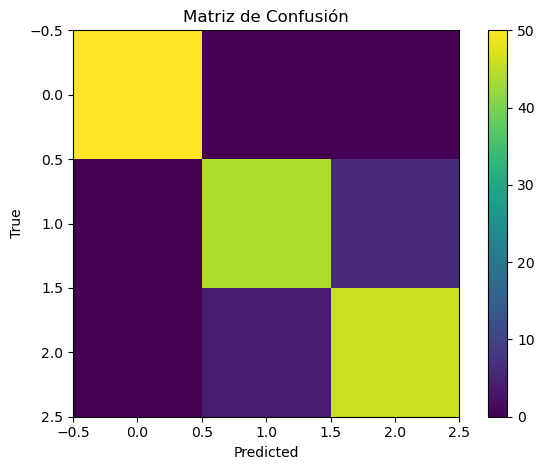

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
y_pred = cross_val_predict(DecisionTreeClassifier(random_state=0), X_i, y_i, cv=skf_i)

cm = confusion_matrix(y_i, y_pred)
print(classification_report(y_i, y_pred))

# Visualización
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de Confusión')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Conclusión

Este notebook actualizado elimina la dependencia de la API de Kaggle, resuelve todos los ejercicios y añade descripciones detalladas de cada tema. Usa este recurso como guía para tus proyectos de ciencia de datos y modelado.
